# Telco Customer Churn — Evaluation

Goal: Evaluate our winning model — Logistic Regression at 
threshold 0.30. Visualize performance, compare all models on ROC curves, 
and use SHAP to explain what is driving predictions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, 
                             roc_curve, classification_report)
from xgboost import XGBClassifier
from matplotlib.patches import Patch

In [6]:
X_train = pd.read_pickle("../data/X_train.pkl")
X_test  = pd.read_pickle("../data/X_test.pkl")
y_train = pd.read_pickle("../data/y_train.pkl")
y_test  = pd.read_pickle("../data/y_test.pkl")

with open("../data/final_model.pkl", "rb") as f:
    lr = pickle.load(f)

lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= 0.30).astype(int)

print("Data and model loaded successfully")
print(f"X_test shape: {X_test.shape}")

Data and model loaded successfully
X_test shape: (1409, 25)


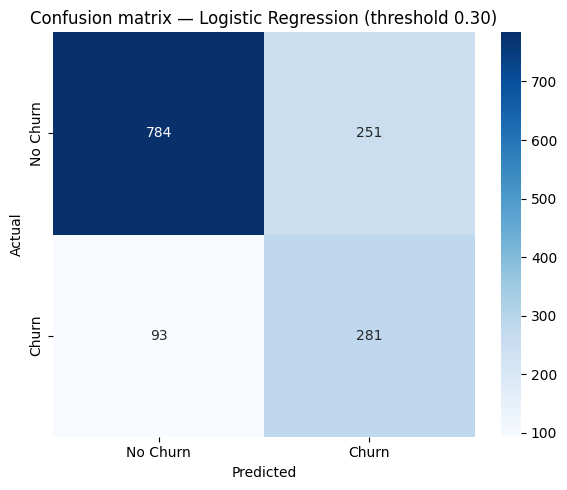

True Negatives  (correctly predicted No Churn): 784
False Positives (wrongly flagged as Churn):     251
False Negatives (missed churners):              93
True Positives  (correctly caught churners):    281

Of 374 actual churners we caught 281 (75.1%)
Of 1035 actual non-churners we wrongly flagged 251 (24.3%)


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=ax)

ax.set_title('Confusion matrix — Logistic Regression (threshold 0.30)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/10_confusion_matrix.png')
plt.show()

# Print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted No Churn): {tn}")
print(f"False Positives (wrongly flagged as Churn):     {fp}")
print(f"False Negatives (missed churners):              {fn}")
print(f"True Positives  (correctly caught churners):    {tp}")
print(f"\nOf {tp + fn} actual churners we caught {tp} ({tp/(tp+fn):.1%})")
print(f"Of {tn + fp} actual non-churners we wrongly flagged {fp} ({fp/(tn+fp):.1%})")

## Confusion matrix findings

Out of 1,409 test customers:

- Correctly identified 281 of 374 churners (75.1% recall)
- Missed 93 churners who received no intervention
- Wrongly flagged 251 non-churners as churn risk (false alarms)
- Correctly cleared 784 loyal customers

Business interpretation:
- 93 missed churners: these are lost customers we could have saved
- 251 false alarms: these customers receive an unnecessary retention 
  offer — a wasted cost but not catastrophic
  
The asymmetry matters: the cost of losing a customer (lifetime value 
lost) almost always exceeds the cost of sending an unnecessary 
retention offer (a discount or outreach call). Our threshold of 0.30 
is calibrated to accept more false alarms in exchange for catching 
more real churners — the right business tradeoff.

## Visual 2: ROC curves — all models
Comparing all three models on a single chart.

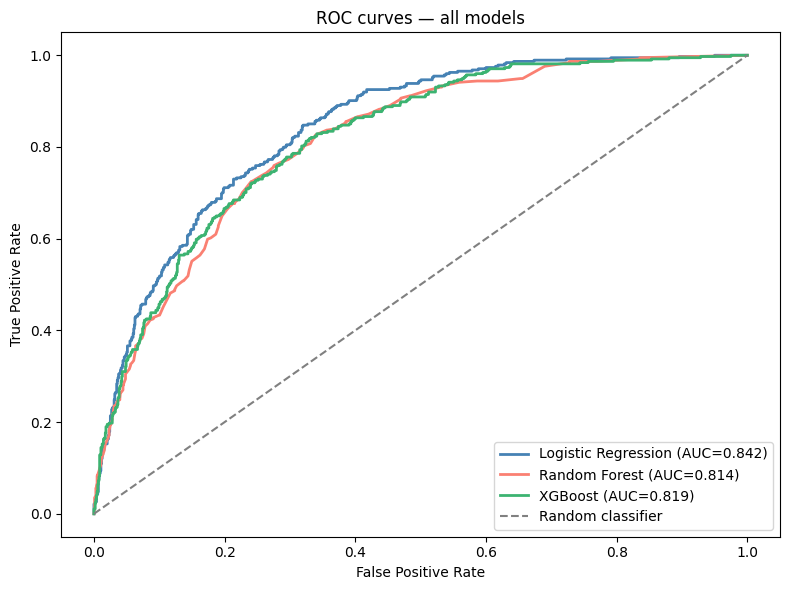

In [8]:
# Retrain all models to get probabilities
rf_balanced = RandomForestClassifier(random_state=42, 
                                     n_jobs=-1,
                                     class_weight='balanced')
rf_balanced.fit(X_train, y_train)
rf_prob = rf_balanced.predict_proba(X_test)[:, 1]

scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale,
                    eval_metric='auc', n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

lr_auc  = roc_auc_score(y_test, lr_prob)
rf_auc  = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(lr_fpr,  lr_tpr,  label=f'Logistic Regression (AUC={lr_auc:.3f})',  
        color='steelblue', linewidth=2)
ax.plot(rf_fpr,  rf_tpr,  label=f'Random Forest (AUC={rf_auc:.3f})',        
        color='salmon', linewidth=2)
ax.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={xgb_auc:.3f})',            
        color='mediumseagreen', linewidth=2)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', 
        label='Random classifier')

ax.set_title('ROC curves — all models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/11_roc_curves.png')
plt.show()

## ROC curve findings

Logistic Regression (AUC=0.842) outperforms both Random Forest (0.814) 
and XGBoost (0.819) across the full curve — not just at one threshold.

The gap is most visible in the 0.0-0.3 false positive rate range — 
exactly where a business wants to operate. At low false alarm rates, 
logistic regression catches significantly more churners than the 
other two models.

This confirms our model selection was correct and that the simplest 
model genuinely fits this data best.

## Visual 3: SHAP feature importance
SHAP (SHapley Additive exPlanations) explains exactly which features 
are driving each prediction and in which direction.

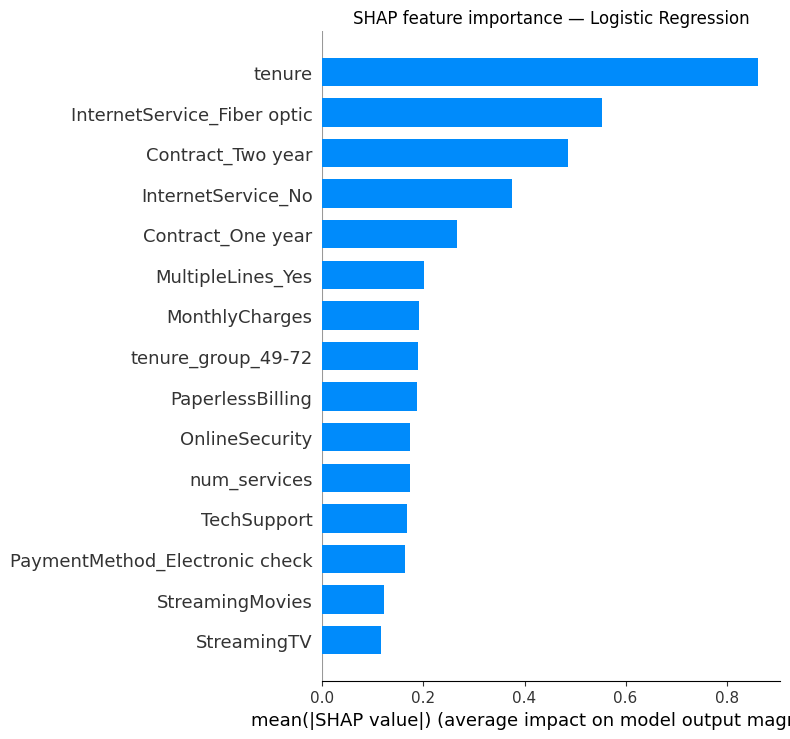

In [9]:
# SHAP for logistic regression
explainer = shap.LinearExplainer(lr, X_train)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('SHAP feature importance — Logistic Regression')
plt.tight_layout()
plt.savefig('../outputs/12_shap_importance.png', bbox_inches='tight')
plt.show()

## SHAP findings — what drives churn predictions

Top 5 features by impact on model predictions:

1. tenure (0.85) — by far the most influential feature. Longer tenure 
   strongly reduces churn probability. New customers are the highest risk.

2. InternetService_Fiber optic (0.55) — fiber optic customers churn 
   significantly more than DSL customers. Likely reflects higher 
   monthly costs and more competitive alternatives in the fiber market.

3. Contract_Two year (0.50) — two year contracts strongly reduce 
   churn probability. The model has learned what our EDA showed — 
   commitment length is the single strongest retention mechanism.

4. InternetService_No (0.38) — customers with no internet service 
   churn less. They are likely phone-only customers on simple, 
   low-cost plans with little reason to switch.

5. Contract_One year (0.27) — one year contracts also reduce churn 
   but less strongly than two year, confirming the graduated 
   protection effect we saw in EDA.

Notable: PaymentMethod_Electronic check appears in the top 15 — 
confirming our EDA finding that electronic check customers are 
higher churn risk.

Our two engineered features both appear:
- tenure_group_49-72: long tenure customers flagged as low risk
- num_services: customers with more services are slightly stickier

Business priority order based on SHAP:
1. Get new customers to commit to longer contracts immediately
2. Investigate why fiber optic customers churn so heavily
3. Target electronic check customers for autopay conversion
4. Focus retention efforts on the first 12 months of tenure

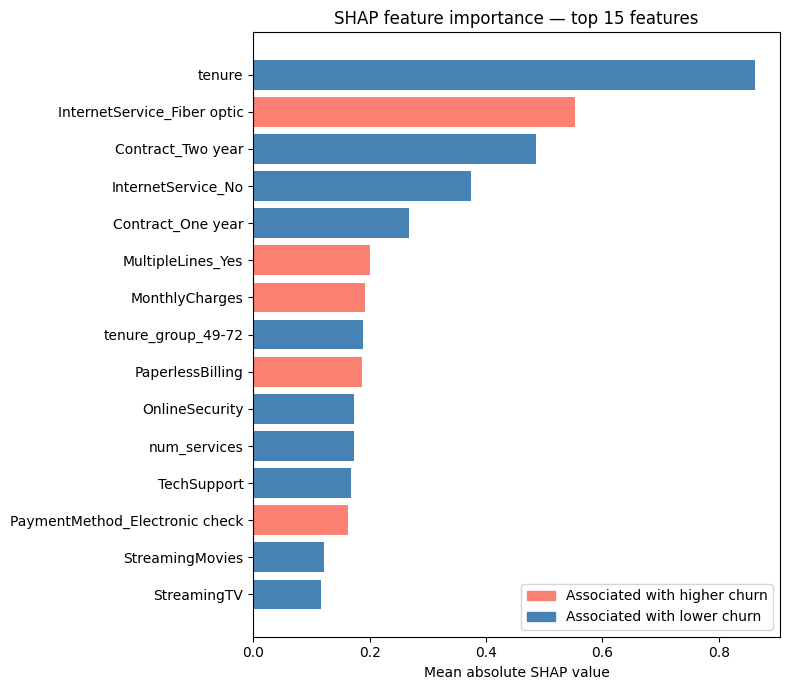

In [ ]:
shap_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))

colors = ['salmon' if f in ['InternetService_Fiber optic', 
                             'PaymentMethod_Electronic check',
                             'PaperlessBilling',
                             'MonthlyCharges',
                             'MultipleLines_Yes'] 
          else 'steelblue' for f in shap_df['feature']]

ax.barh(shap_df['feature'], shap_df['importance'], color=colors)
ax.set_title('SHAP feature importance — top 15 features')
ax.set_xlabel('Mean absolute SHAP value')

legend = [Patch(color='salmon', label='Associated with higher churn'),
          Patch(color='steelblue', label='Associated with lower churn')]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/13_shap_importance_colored.png', bbox_inches='tight')
plt.show()

## SHAP colored importance — direction of effect

Blue bars reduce churn probability (protective factors)
Salmon bars increase churn probability (risk factors)

Top protective factors (blue):
- tenure: longest serving customers are safest
- Contract_Two year: two year commitment strongly reduces risk
- InternetService_No: simple phone-only customers rarely leave
- Contract_One year: medium commitment still meaningfully protective
- OnlineSecurity, TechSupport, num_services: supported customers stay

Top risk factors (salmon):
- InternetService_Fiber optic: fiber customers are highest risk
- MultipleLines_Yes: multiple line customers churn more
- MonthlyCharges: higher bills increase churn risk
- PaperlessBilling: paperless customers are slightly more at risk
- PaymentMethod_Electronic check: manual payers are higher risk

The pattern is clear: customers who are newer, paying more, on 
flexible contracts, and using fiber optic internet are the highest 
risk segment. Customers who are long tenured, on annual or two year 
contracts, with online security and tech support are the safest.

## Evaluation summary

Model: Logistic Regression, threshold 0.30
ROC-AUC: 0.842

Confusion matrix results on 1,409 test customers:
- Caught 281 of 374 churners (75.1% recall)
- Missed 93 churners
- 251 false alarms out of 1,035 loyal customers

Top 3 actionable insights from SHAP:
1. Move month-to-month customers to annual contracts immediately
2. Investigate fiber optic service quality and pricing
3. Incentivize electronic check customers to switch to autopay

What I would do differently:
- Collect customer satisfaction scores — likely highly predictive
- Explore customer service call logs as a feature
- Test a cost-sensitive learning approach using actual customer 
  lifetime value to weight the loss function
- Deploy the model as a weekly scoring pipeline rather than 
  a one-time prediction